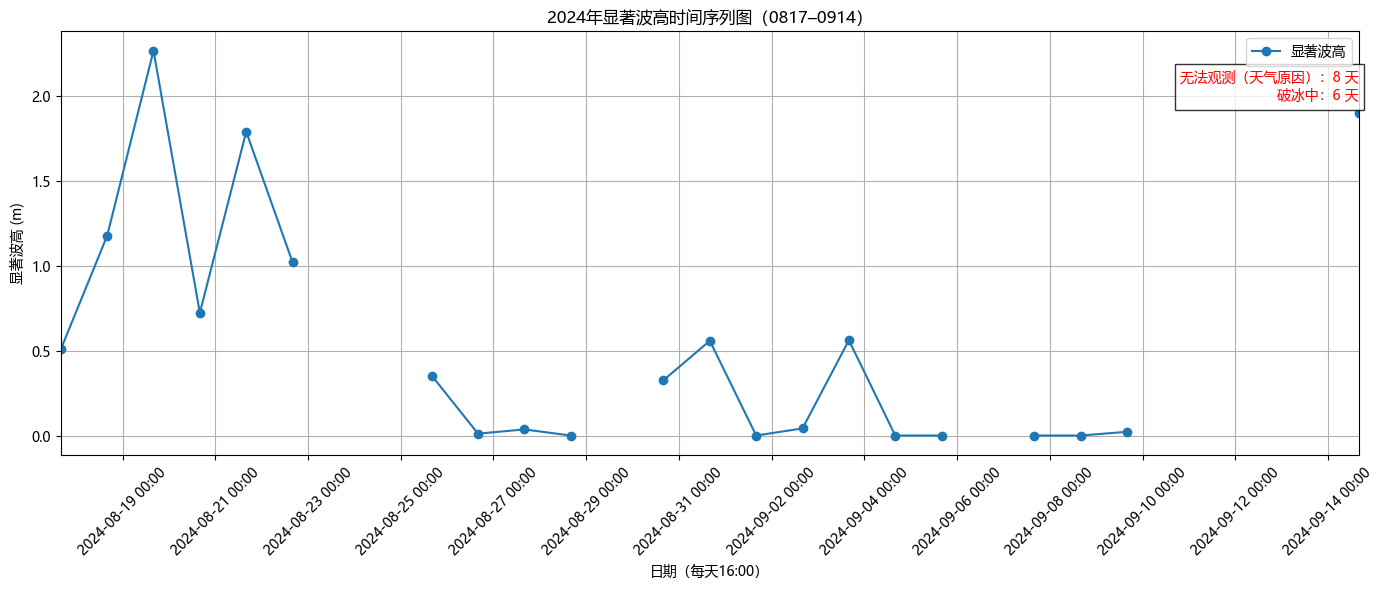

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates
from datetime import datetime

# 设置中文字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 转换日期编码，如0817 → 2024-08-17 16:00
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)

date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 5]

# 统计特殊情况
num_nan = h_sig_col.isna().sum()
num_zero = (h_sig_col == 0).sum()

# 绘图
plt.figure(figsize=(14, 6))
plt.plot(date_col, h_sig_col, marker='o', linestyle='-', label='显著波高')

# 设置时间格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-17 16:00')
end_date = pd.Timestamp('2024-09-14 16:00')
plt.xlim([start_date, end_date])

# 添加总结文字（右上角）
summary_text = f"无法观测（天气原因）：{num_nan} 天\n破冰中：{num_zero} 天"
plt.text(end_date, max(h_sig_col.fillna(0)) * 0.95, summary_text,
         ha='right', va='top', fontsize=10, color='red', bbox=dict(facecolor='white', alpha=0.8))

# 美化
plt.xlabel('日期（每天16:00）')
plt.ylabel('显著波高 (m)')
plt.title('2024年显著波高时间序列图（0817–0914）')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


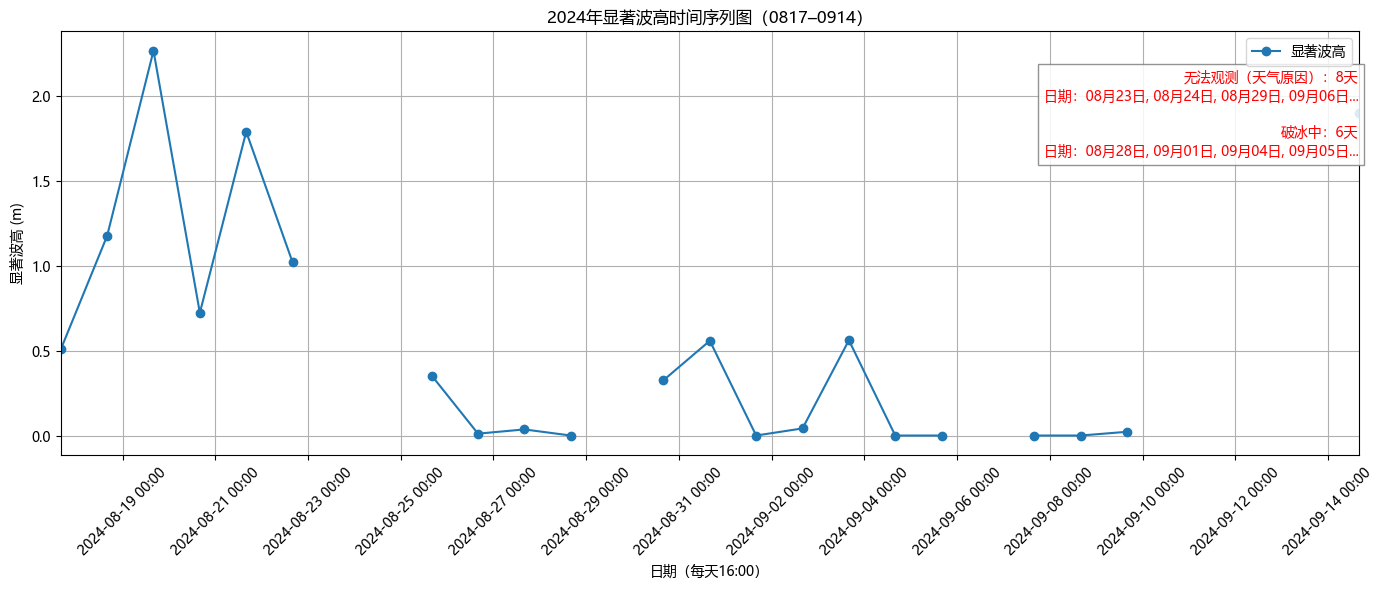

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates
from datetime import datetime

# 设置中文字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 将如0817 → 转为 datetime 格式（2024年+16:00）
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)

date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 5]

# 找出无法观测和破冰中对应的日期
unobservable_dates = date_col[h_sig_col.isna()].dt.strftime('%m月%d日').tolist()
icebreaking_dates = date_col[h_sig_col == 0].dt.strftime('%m月%d日').tolist()

# 准备右上角显示的注释文本（限制长度）
summary_text = f"无法观测（天气原因）：{len(unobservable_dates)}天\n"
summary_text += "日期：" + ", ".join(unobservable_dates[:4]) + ("..." if len(unobservable_dates) > 4 else "") + "\n\n"
summary_text += f"破冰中：{len(icebreaking_dates)}天\n"
summary_text += "日期：" + ", ".join(icebreaking_dates[:4]) + ("..." if len(icebreaking_dates) > 4 else "")

# 绘图
plt.figure(figsize=(14, 6))
plt.plot(date_col, h_sig_col, marker='o', linestyle='-', label='显著波高')

# 设置时间格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-17 16:00')
end_date = pd.Timestamp('2024-09-14 16:00')
plt.xlim([start_date, end_date])

# 添加注释（右上角）
plt.text(end_date, max(h_sig_col.fillna(0)) * 0.95, summary_text,
         ha='right', va='top', fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85))

# 图表美化
plt.xlabel('日期（每天16:00）')
plt.ylabel('显著波高 (m)')
plt.title('2024年显著波高时间序列图（0817–0914）')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


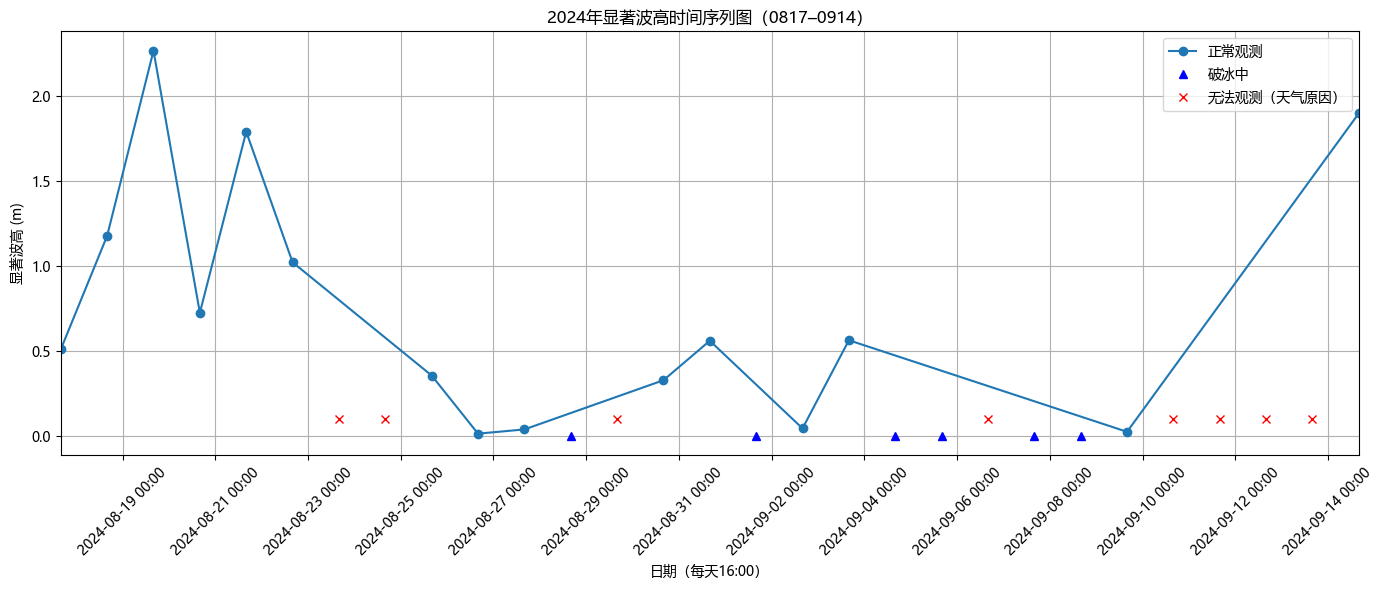

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates

# 设置中文字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 将如0817 → 转为 datetime 格式（2024年 + 16:00）
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)

date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 5]

# 分类索引
normal_idx = (~h_sig_col.isna()) & (h_sig_col != 0)
icebreaking_idx = (h_sig_col == 0)
unobservable_idx = h_sig_col.isna()

# 绘图
plt.figure(figsize=(14, 6))

# 正常观测（○）
plt.plot(date_col[normal_idx], h_sig_col[normal_idx], 'o-', label='正常观测')

# 破冰中（▲）
plt.plot(date_col[icebreaking_idx], [0]*icebreaking_idx.sum(), '^', color='blue', label='破冰中')

# 无法观测（×，设定一个略高位置仅用于展示）
plt.plot(date_col[unobservable_idx], [0.1]*unobservable_idx.sum(), 'x', color='red', label='无法观测（天气原因）')

# 时间格式美化
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-17 16:00')
end_date = pd.Timestamp('2024-09-14 16:00')
plt.xlim([start_date, end_date])

# 图形标签
plt.xlabel('日期（每天16:00）')
plt.ylabel('显著波高 (m)')
plt.title('2024年显著波高时间序列图（0817–0914）')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


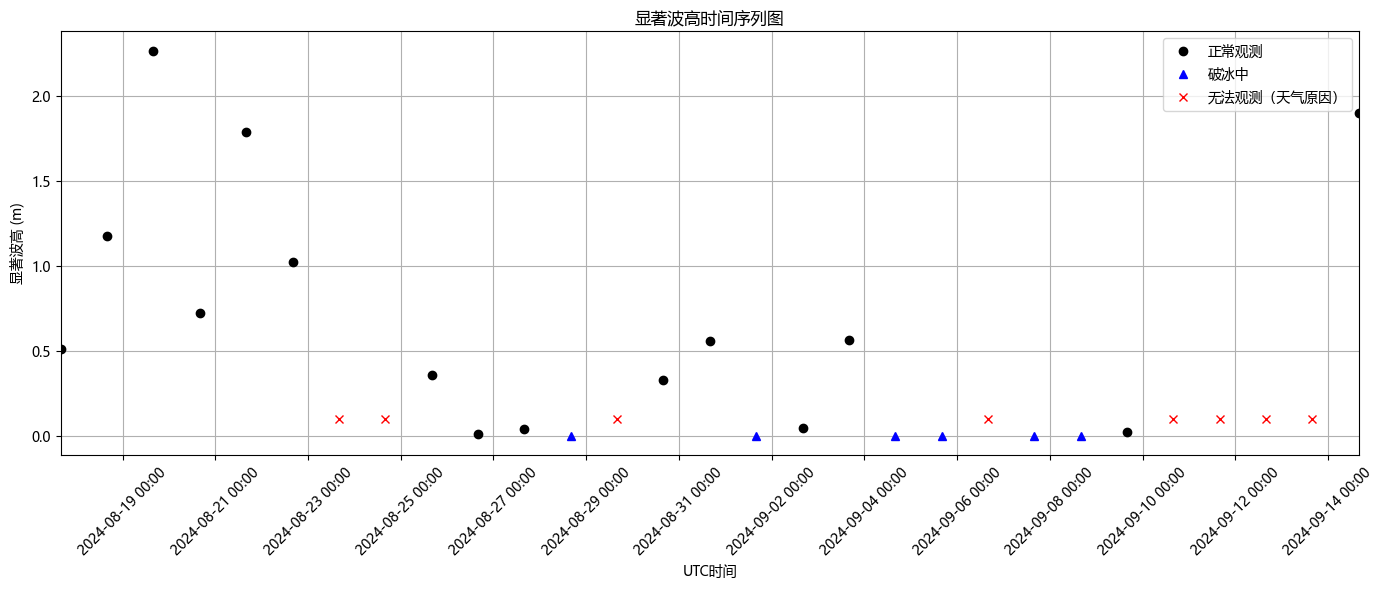

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates

# 设置中文字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 将如0817 → 转为 datetime 格式（2024年 + 16:00）
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)

date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 5]

# 分类索引
normal_idx = (~h_sig_col.isna()) & (h_sig_col != 0)
icebreaking_idx = (h_sig_col == 0)
unobservable_idx = h_sig_col.isna()

# 创建图形
plt.figure(figsize=(14, 6))

# 正常观测：○
plt.plot(date_col[normal_idx], h_sig_col[normal_idx], 'o', color='black', label='正常观测')

# 破冰中：▲
plt.plot(date_col[icebreaking_idx], [0]*icebreaking_idx.sum(), '^', color='blue', label='破冰中')

# 无法观测：×（设为 0.1 位置展示，不影响实际数据）
plt.plot(date_col[unobservable_idx], [0.1]*unobservable_idx.sum(), 'x', color='red', label='无法观测（天气原因）')

# 设置时间格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-17 16:00')
end_date = pd.Timestamp('2024-09-14 16:00')
plt.xlim([start_date, end_date])

# 图表美化
plt.xlabel('UTC时间')
plt.ylabel('显著波高 (m)')
plt.title('显著波高时间序列图')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


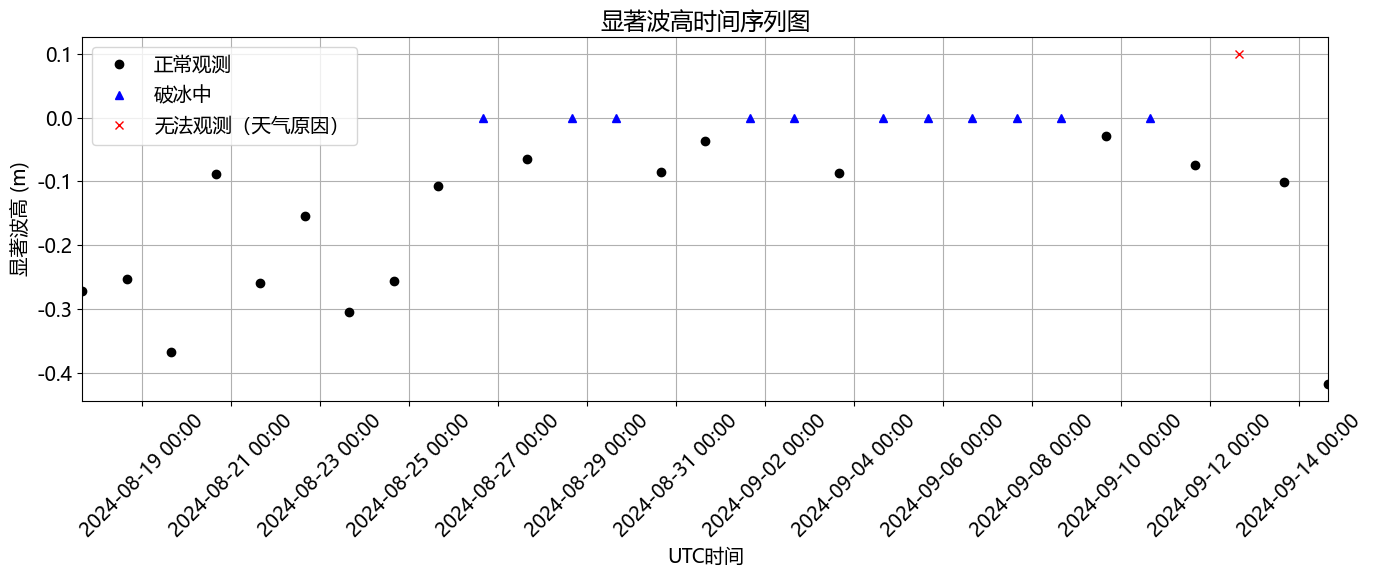

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates

# 设置中文字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 将如0817 → 转为 datetime 格式（2024年 + 16:00）
# 将如0817 → 转为 datetime 格式（2024年 + 16:00）
def convert_to_datetime(code):
    if pd.isna(code):
        return pd.NaT
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)


date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 5]

# 分类索引
normal_idx = (~h_sig_col.isna()) & (h_sig_col != 0)
icebreaking_idx = (h_sig_col == 0)
unobservable_idx = h_sig_col.isna()

# 创建图形
plt.figure(figsize=(14, 6))

# 正常观测：○
plt.plot(date_col[normal_idx], h_sig_col[normal_idx], 'o', color='black', label='正常观测')

# 破冰中：▲
plt.plot(date_col[icebreaking_idx], [0]*icebreaking_idx.sum(), '^', color='blue', label='破冰中')

# 无法观测：×（设为 0.1 位置展示，不影响实际数据）
plt.plot(date_col[unobservable_idx], [0.1]*unobservable_idx.sum(), 'x', color='red', label='无法观测（天气原因）')

# 设置时间格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-17 16:00')
end_date = pd.Timestamp('2024-09-14 16:00')
plt.xlim([start_date, end_date])

# 图表美化
plt.xlabel('UTC时间')
plt.ylabel('显著波高 (m)')
plt.title('显著波高时间序列图')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


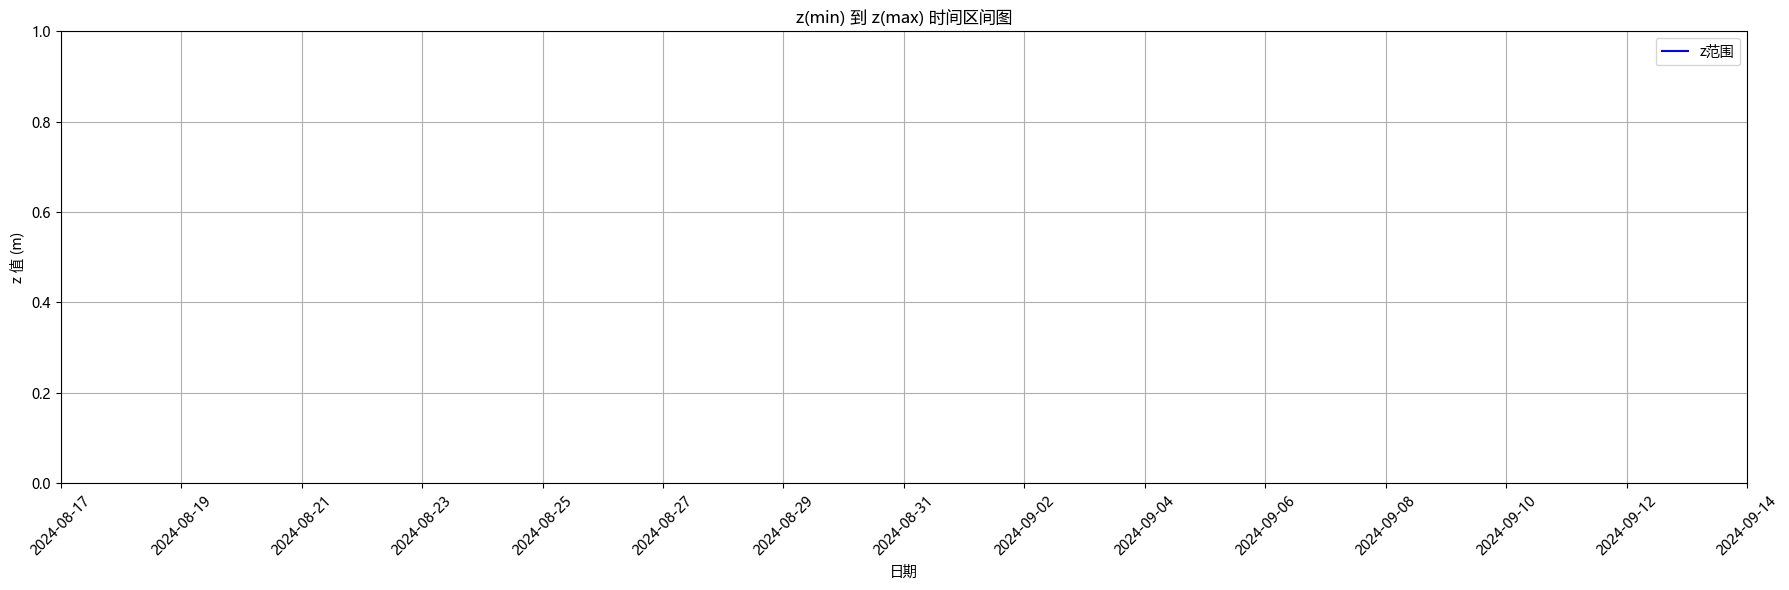

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates

# 设置中文字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 转换日期
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)

date_col = df.iloc[:, 0].apply(convert_to_datetime)

# 清洗 z(min) 和 z(max)
z_min = pd.to_numeric(df.iloc[:, 6], errors='coerce')
z_max = pd.to_numeric(df.iloc[:, 7], errors='coerce')

# 清洗后，剔除无效数据
valid = (~z_min.isna()) & (~z_max.isna())
dates = date_col[valid]
zmin = z_min[valid]
zmax = z_max[valid]

# # 创建图形
# plt.figure(figsize=(14, 6))

# # 画出区间（竖线 + 顶部横线 + 底部横线）
# plt.vlines(dates, zmin, zmax, color='blue', label='z范围')
# plt.hlines(zmin, dates - pd.Timedelta(hours=6), dates + pd.Timedelta(hours=6), color='blue')
# plt.hlines(zmax, dates - pd.Timedelta(hours=6), dates + pd.Timedelta(hours=6), color='blue')

# # 设置时间轴格式
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
# plt.xticks(rotation=45)

# # 设置标题和标签
# plt.title('z(min) 到 z(max) 时间区间图')
# plt.xlabel('日期')
# plt.ylabel('z 值 (m)')
# plt.grid(True)
# plt.tight_layout()
# plt.legend()
# plt.show()

# 优化后的绘图（用 ±1 小时横线）
plt.figure(figsize=(18, 6))  # 更宽一点

# 限定时间范围
plt.xlim(pd.Timestamp('2024-08-17'), pd.Timestamp('2024-09-14'))

# 使用更小的横线宽度
delta = pd.Timedelta(hours=1)
plt.vlines(dates, zmin, zmax, color='blue', label='z范围')
plt.hlines(zmin, dates - delta, dates + delta, color='blue')
plt.hlines(zmax, dates - delta, dates + delta, color='blue')

# 美化时间轴
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

# 图表信息
plt.title('z(min) 到 z(max) 时间区间图')
plt.xlabel('日期')
plt.ylabel('z 值 (m)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


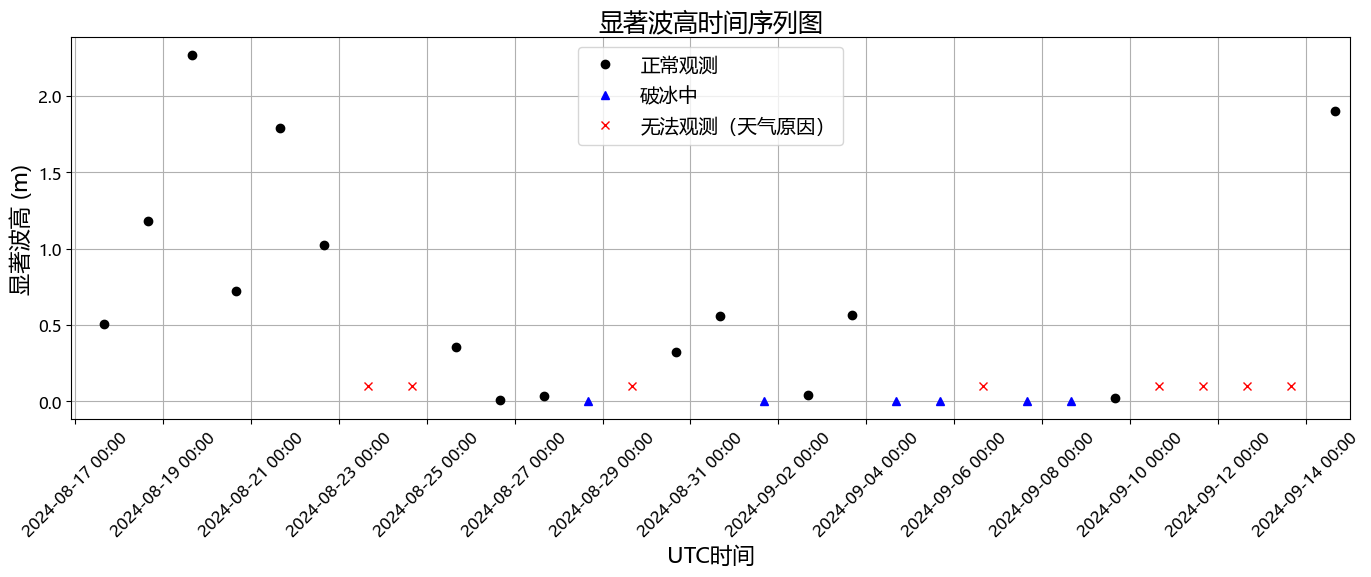

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates

# 设置中文字体和字号
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 14  # 全局字体大小

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 将如0817 → 转为 datetime 格式（2024年 + 16:00）
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)

date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 5]

# 分类索引
normal_idx = (~h_sig_col.isna()) & (h_sig_col != 0)
icebreaking_idx = (h_sig_col == 0)
unobservable_idx = h_sig_col.isna()

# 创建图形
plt.figure(figsize=(14, 6))

# 正常观测：○
plt.plot(date_col[normal_idx], h_sig_col[normal_idx], 'o', color='black', label='正常观测')

# 破冰中：▲
plt.plot(date_col[icebreaking_idx], [0]*icebreaking_idx.sum(), '^', color='blue', label='破冰中')

# 无法观测：×（设为 0.1 位置展示，不影响实际数据）
plt.plot(date_col[unobservable_idx], [0.1]*unobservable_idx.sum(), 'x', color='red', label='无法观测（天气原因）')

# 设置时间格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-16 22:00')
end_date = pd.Timestamp('2024-09-15 00:00')
plt.xlim([start_date, end_date])

# 设置大字号标签
plt.xlabel('UTC时间', fontsize=16)
plt.ylabel('显著波高 (m)', fontsize=16)
plt.title('显著波高时间序列图', fontsize=18)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()


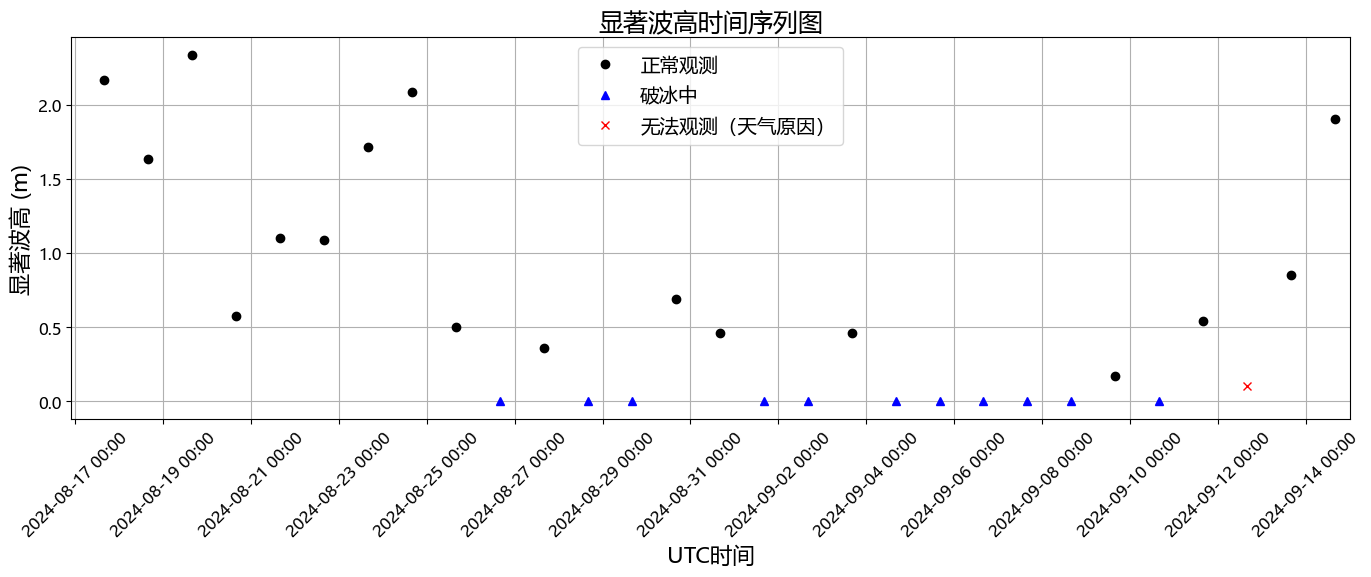

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates

# 设置中文字体和字号
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 14  # 全局字体大小

# 读取 Excel 文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 将如0817 → 转为 datetime 格式（2024年 + 16:00）
def convert_to_datetime(code):
    if pd.isna(code):
        return pd.NaT
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day, hour=16)


date_col = df.iloc[:, 0].apply(convert_to_datetime)
h_sig_col = df.iloc[:, 8]

# 分类索引
normal_idx = (~h_sig_col.isna()) & (h_sig_col != 0)
icebreaking_idx = (h_sig_col == 0)
unobservable_idx = h_sig_col.isna()

# 创建图形
plt.figure(figsize=(14, 6))

# 正常观测：○
plt.plot(date_col[normal_idx], h_sig_col[normal_idx], 'o', color='black', label='正常观测')

# 破冰中：▲
plt.plot(date_col[icebreaking_idx], [0]*icebreaking_idx.sum(), '^', color='blue', label='破冰中')

# 无法观测：×（设为 0.1 位置展示，不影响实际数据）
plt.plot(date_col[unobservable_idx], [0.1]*unobservable_idx.sum(), 'x', color='red', label='无法观测（天气原因）')

# 设置时间格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 固定X轴范围
start_date = pd.Timestamp('2024-08-16 22:00')
end_date = pd.Timestamp('2024-09-15 00:00')
plt.xlim([start_date, end_date])

# 设置大字号标签
plt.xlabel('UTC时间', fontsize=16)
plt.ylabel('显著波高 (m)', fontsize=16)
plt.title('显著波高时间序列图', fontsize=18)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()



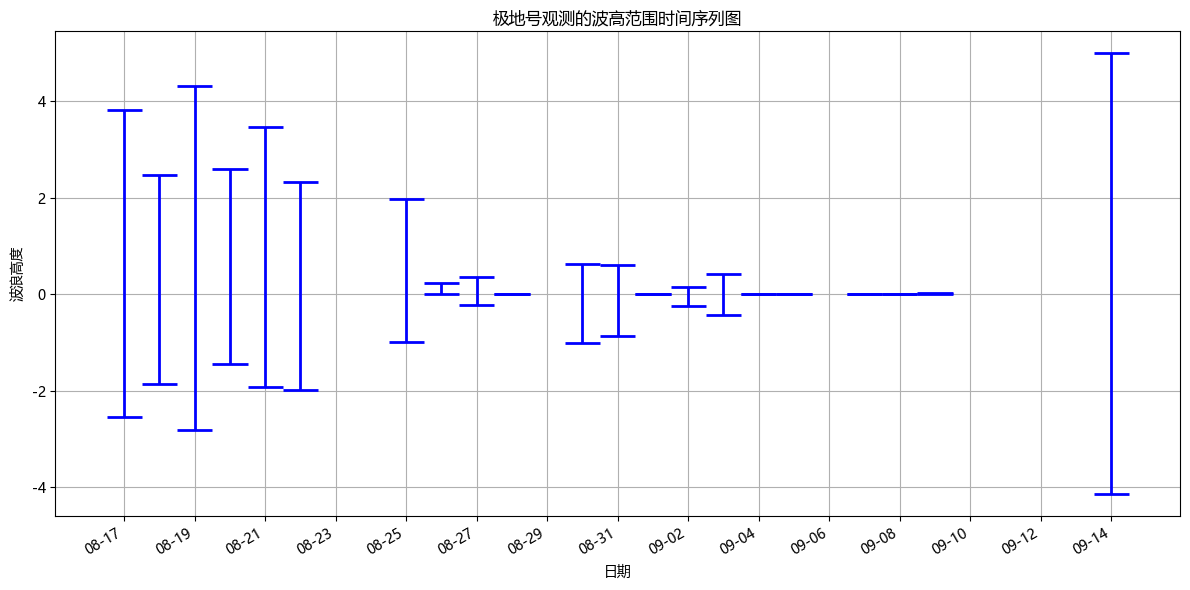

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文字体（可选）
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# === 读取数据 ===
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 日期转换（假设日期列是 0817 这种格式）
def convert_to_datetime(code):
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day)

df['日期'] = df.iloc[:, 0].apply(convert_to_datetime)
df['z_min'] = pd.to_numeric(df.iloc[:, 2], errors='coerce')
df['z_max'] = pd.to_numeric(df.iloc[:, 3], errors='coerce')

# === 绘图 ===
fig, ax = plt.subplots(figsize=(12, 6))

# 画每个日期的一根竖线
ax.vlines(df['日期'], df['z_min'], df['z_max'], color='blue', linewidth=2)

# 画顶端和底端的小横线
cap_width = 0.5  # 横线宽度（天数单位）
ax.hlines(df['z_min'], df['日期'] - pd.to_timedelta(cap_width, unit='d'), 
          df['日期'] + pd.to_timedelta(cap_width, unit='d'), color='blue', linewidth=2)
ax.hlines(df['z_max'], df['日期'] - pd.to_timedelta(cap_width, unit='d'), 
          df['日期'] + pd.to_timedelta(cap_width, unit='d'), color='blue', linewidth=2)

# 设置X轴格式
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # 每2天一个标签
fig.autofmt_xdate()

# 添加标题和标签
ax.set_xlabel('日期')
ax.set_ylabel('波浪高度')
ax.set_title('极地号观测的波高范围时间序列图')

plt.grid(True)
plt.tight_layout()
plt.show()


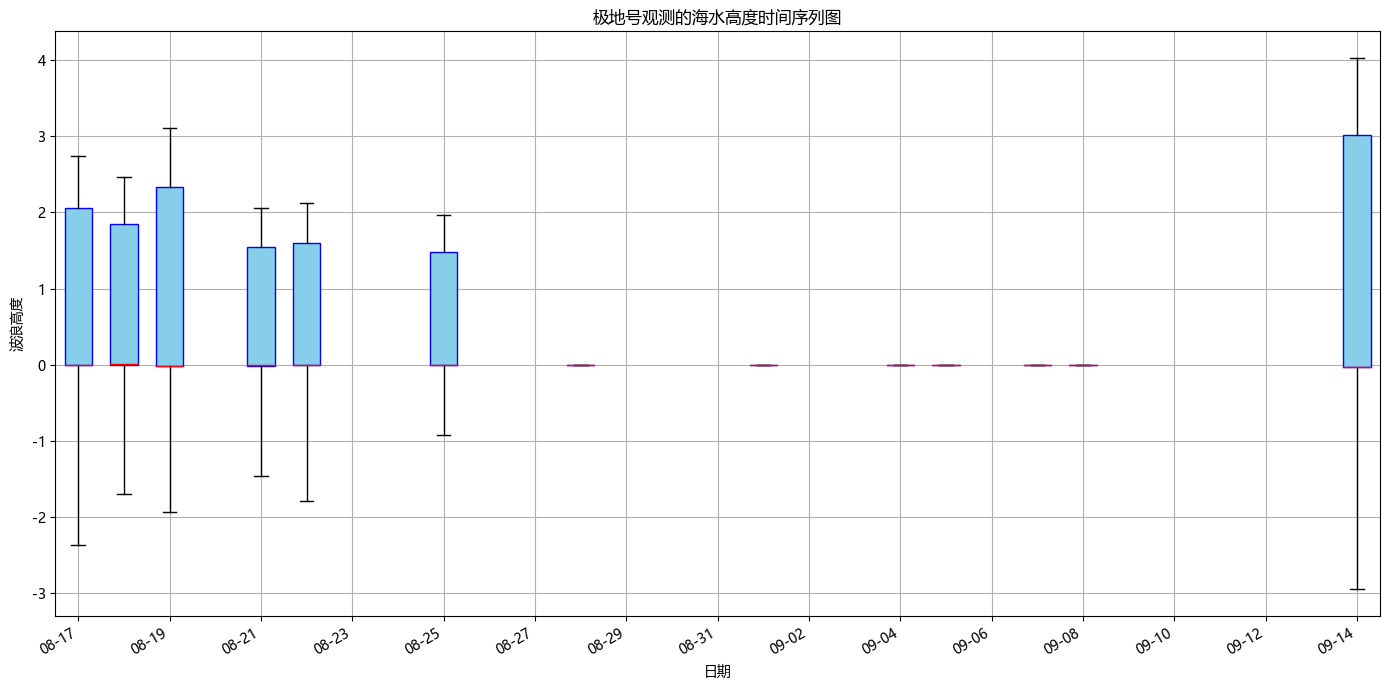

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# 设置中文
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# === 读取数据 ===
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 日期转换
def convert_to_datetime(code):
    if pd.isna(code):
        return pd.NaT
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day)

df['日期'] = df.iloc[:, 0].apply(convert_to_datetime)
df['z_min'] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
df['z_max'] = pd.to_numeric(df.iloc[:, 2], errors='coerce')
df['median'] = pd.to_numeric(df.iloc[:, 3], errors='coerce')
df['Q1'] = pd.to_numeric(df.iloc[:, 4], errors='coerce')
df['Q3'] = pd.to_numeric(df.iloc[:, 5], errors='coerce')

df = df.dropna(subset=['日期'])

# === 准备模拟样本数据 ===
all_samples = []
valid_dates = []

for idx, row in df.iterrows():
    if pd.isna(row['z_min']) or pd.isna(row['z_max']) or pd.isna(row['Q1']) or pd.isna(row['median']) or pd.isna(row['Q3']):
        continue
    # 用五个数造一组模拟数据（10个点）
    samples = [
        row['z_min'],
        row['Q1'],
        row['Q1'],
        row['median'],
        row['median'],
        row['median'],
        row['Q3'],
        row['Q3'],
        row['z_max'],
        row['z_max']
    ]
    all_samples.append(samples)
    valid_dates.append(row['日期'])

# === 绘制真正的箱型图 ===
fig, ax = plt.subplots(figsize=(14, 7))

# 位置参数：每个箱子对应一个位置
positions = mdates.date2num(valid_dates)

# 绘制
ax.boxplot(
    all_samples,
    positions=positions,
    widths=0.6,  # 箱子宽度
    patch_artist=True,  # 填充颜色
    boxprops=dict(facecolor='skyblue', color='blue'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=5, linestyle='none')
)

# 设置x轴
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig.autofmt_xdate()
# 添加标题和标签
ax.set_xlabel('日期')
ax.set_ylabel('海水高度')
ax.set_title('极地号观测的海水高度时间序列图')

plt.grid(True)
plt.tight_layout()
plt.show()


D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


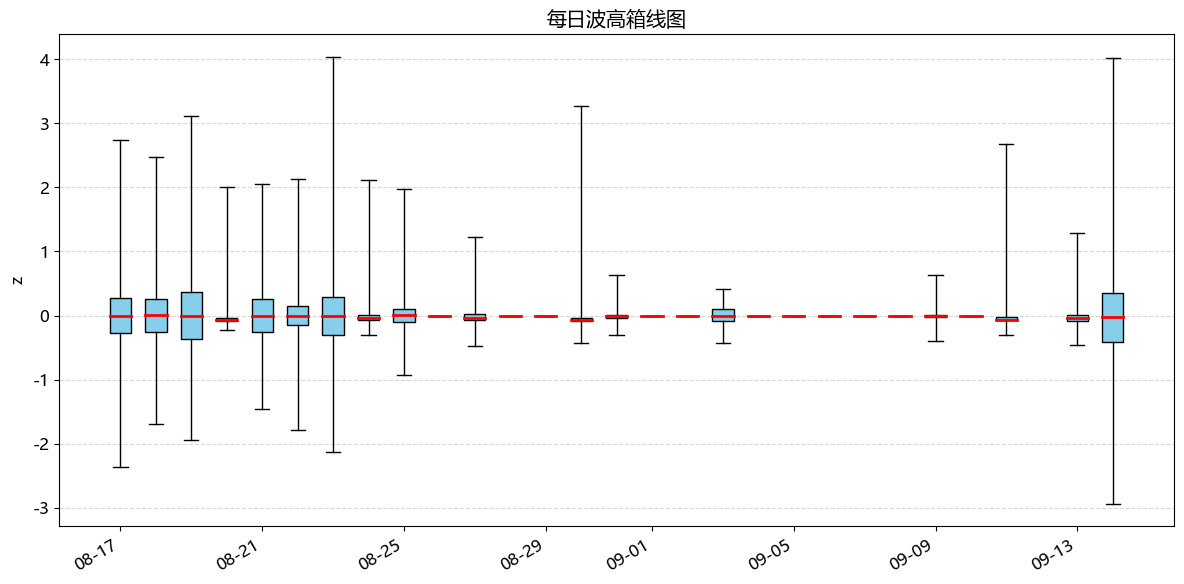

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from datetime import datetime, timedelta

# 设置字体和风格
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 12

# === 读取 Excel 文件 ===
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# === 将 '0817' 这类日期转为 datetime ===
def parse_date(code):
    try:
        code_str = str(int(code)).zfill(4)
        month = int(code_str[:2])
        day = int(code_str[2:])
        return datetime(2024, month, day)
    except:
        return pd.NaT

df = df.copy()
df['日期'] = df.iloc[:, 0].apply(parse_date)
df = df[df['日期'].notna()]

# === 重命名列名以便调用 ===
df = df.rename(columns={
    df.columns[2]: 'z_min',
    df.columns[5]: 'Q1',
    df.columns[4]: '中位数',
    df.columns[6]: 'Q4',
    df.columns[3]: 'z_max'
})

# 删除包含NaN的行
df_clean = df[['日期', 'z_min', 'Q1', '中位数', 'Q4', 'z_max']].dropna()

# === 绘制图形 ===
plt.figure(figsize=(12, 6))

for _, row in df_clean.iterrows():
    x = row['日期']
    x0 = x - timedelta(days=0.3)
    x1 = x + timedelta(days=0.3)

    # 须线（竖线部分）
    plt.plot([x, x], [row['z_min'], row['Q1']], color='black', linewidth=1)
    plt.plot([x, x], [row['Q4'], row['z_max']], color='black', linewidth=1)

    # 须线末端添加水平短横线
    whisker_width = timedelta(days=0.2)
    plt.plot([x - whisker_width, x + whisker_width], [row['z_min'], row['z_min']], color='black', linewidth=1)
    plt.plot([x - whisker_width, x + whisker_width], [row['z_max'], row['z_max']], color='black', linewidth=1)

    # 箱体（Q1-Q4）
    plt.fill_between([x0, x1], row['Q1'], row['Q4'], color='skyblue', edgecolor='black')

    # 中位数线
    plt.plot([x0, x1], [row['中位数'], row['中位数']], color='red', linewidth=2)

# === 时间格式美化 ===
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gcf().autofmt_xdate()
plt.ylabel("z")
plt.title("每日波高箱线图")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


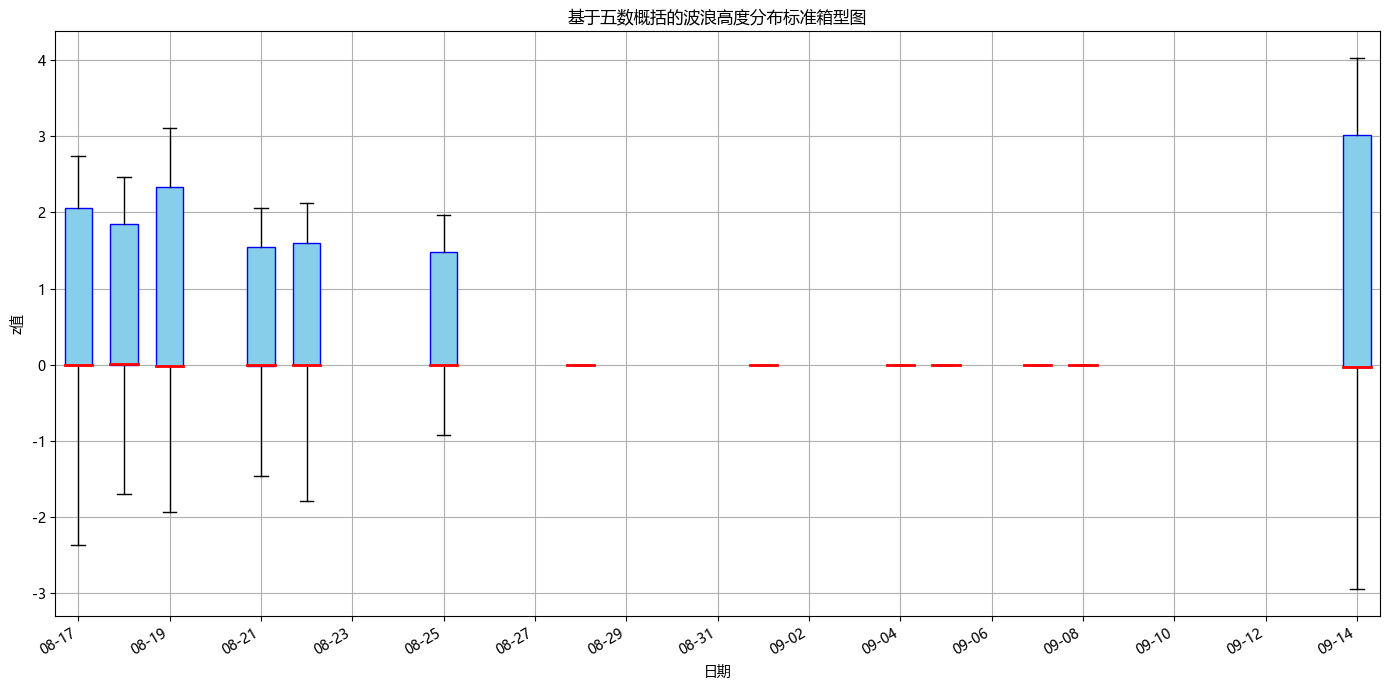

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# === 读取数据 ===
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 日期转换
def convert_to_datetime(code):
    if pd.isna(code):
        return pd.NaT
    code_str = str(int(code)).zfill(4)
    month = int(code_str[:2])
    day = int(code_str[2:])
    return pd.Timestamp(year=2024, month=month, day=day)

df['日期'] = df.iloc[:, 0].apply(convert_to_datetime)
df['z_min'] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
df['z_max'] = pd.to_numeric(df.iloc[:, 2], errors='coerce')
df['median'] = pd.to_numeric(df.iloc[:, 3], errors='coerce')
df['Q1'] = pd.to_numeric(df.iloc[:, 4], errors='coerce')
df['Q3'] = pd.to_numeric(df.iloc[:, 5], errors='coerce')

df = df.dropna(subset=['日期'])

# === 准备模拟样本数据 ===
all_samples = []
valid_dates = []

for idx, row in df.iterrows():
    if pd.isna(row['z_min']) or pd.isna(row['z_max']) or pd.isna(row['Q1']) or pd.isna(row['median']) or pd.isna(row['Q3']):
        continue
    # 模拟每一天的样本数据
    samples = [
        row['z_min'],
        row['Q1'],
        row['Q1'],
        row['median'],
        row['median'],
        row['median'],
        row['Q3'],
        row['Q3'],
        row['z_max'],
        row['z_max']
    ]
    all_samples.append(samples)
    valid_dates.append(row['日期'])

# === 绘图 ===
fig, ax = plt.subplots(figsize=(14, 7))

# 位置参数
positions = mdates.date2num(valid_dates)

# 画箱型图
box = ax.boxplot(
    all_samples,
    positions=positions,
    widths=0.6,
    patch_artist=True,  # 填充颜色
    boxprops=dict(facecolor='skyblue', color='blue'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=5, linestyle='none')
)

# === 手动重新画中位数线 ===
for median_line in box['medians']:
    x, y = median_line.get_data()
    ax.plot(x, y, color='red', linewidth=2, zorder=10)  # zorder=10表示最上层

# 设置x轴
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig.autofmt_xdate()

# 添加标签和标题
ax.set_xlabel('日期')
ax.set_ylabel('z值')
ax.set_title('基于五数概括的波浪高度分布标准箱型图')

plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
pip install graphviz


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simpleNote: you may need to restart the kernel to use updated packages.


In [1]:
from graphviz import Digraph

dot = Digraph(comment='Wave Parameter Inversion Pipeline', format='png')
dot.attr(rankdir='TB', size='8')

# 添加阶段标签
dot.attr('node', shape='plaintext')
dot.node('Stage1', 'IMAGE PROCESSING')
dot.node('Stage2', 'IMAGE MATCHING')
dot.node('Stage3', '3D RECONSTRUCTION')
dot.node('Stage4', 'SURFACE GRIDDING')

# 添加流程节点
dot.attr('node', shape='box', style='rounded')

dot.node('A1', 'Load Image & Camera Parameters')
dot.node('A2', 'CLAHE')

dot.node('B1', 'SURF Keypoint Detection')
dot.node('B2', 'Feature Matching')
dot.node('B3', 'Essential Matrix Estimation')

dot.node('C1', 'Rectification')
dot.node('C2', 'Disparity Computation')
dot.node('C3', '3D Plane Fitting')

dot.node('D1', 'DCT Interpolation')

# 连接流程
dot.edges([
    ('A1', 'A2'),
    ('A2', 'B1'),
    ('B1', 'B2'),
    ('B2', 'B3'),
    ('B3', 'C1'),
    ('C1', 'C2'),
    ('C2', 'C3'),
    ('C3', 'D1')
])

# 渲染图像文件（并显示）
dot.render('wave_inversion_flowchart', view=True)


'wave_inversion_flowchart.png'

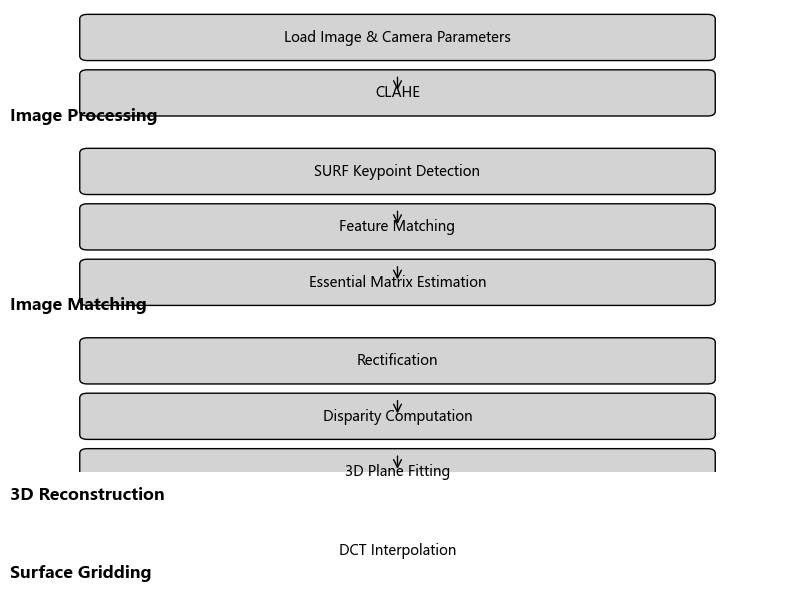

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

steps = [
    ("Image Processing", ["Load Image & Camera Parameters", "CLAHE"]),
    ("Image Matching", ["SURF Keypoint Detection", "Feature Matching", "Essential Matrix Estimation"]),
    ("3D Reconstruction", ["Rectification", "Disparity Computation", "3D Plane Fitting"]),
    ("Surface Gridding", ["DCT Interpolation"])
]

fig, ax = plt.subplots(figsize=(10, 6))
y = 0
for group, tasks in steps:
    for task in tasks:
        ax.add_patch(mpatches.FancyBboxPatch((1, y), 8, 0.8, boxstyle="round,pad=0.1", edgecolor='black', facecolor='lightgray'))
        ax.text(5, y + 0.4, task, ha='center', va='center', fontsize=10)
        y -= 1.2
    y -= 0.5
    ax.text(0, y + 1.5, group, fontsize=12, fontweight='bold')

# 添加箭头
y = 0
for group, tasks in steps:
    for i in range(len(tasks) - 1):
        ax.annotate("", xy=(5, y - 0.8), xytext=(5, y - 0.4),
                    arrowprops=dict(arrowstyle="->", lw=1))
        y -= 1.2
    y -= 1.7

ax.set_xlim(0, 10)
ax.set_ylim(-9, 1)
ax.axis('off')
plt.show()


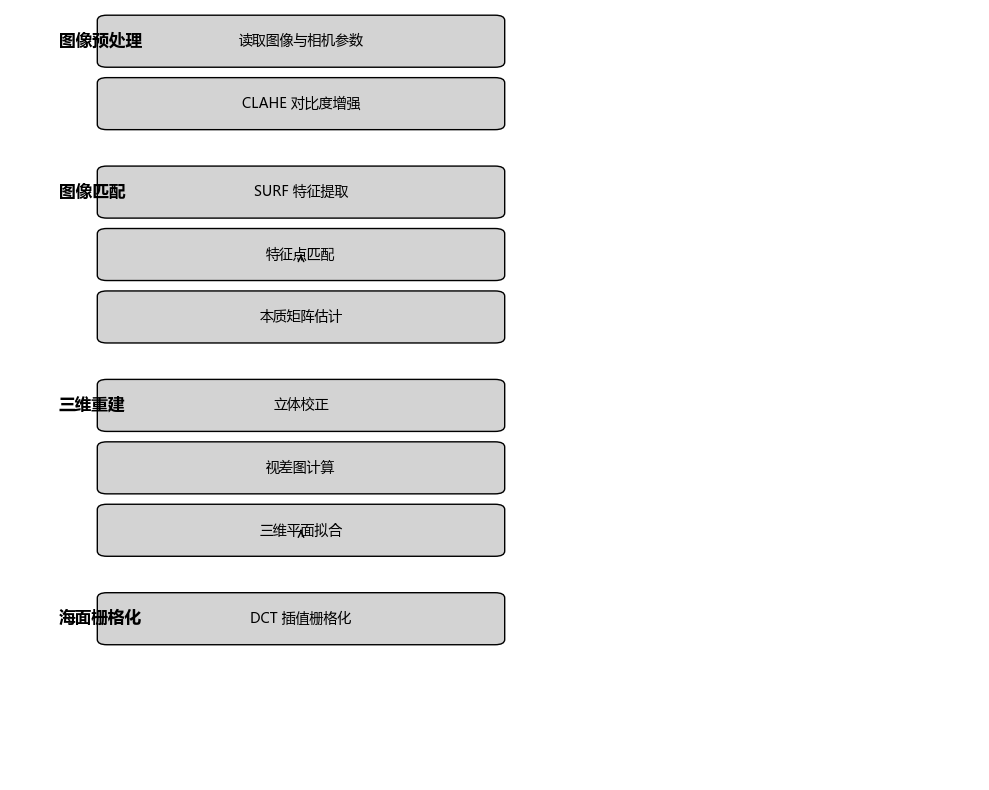

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates
# 设置中文字体和字号
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 10  # 全局字体大小
# 中文任务步骤
steps = [
    ("图像预处理", ["读取图像与相机参数", "CLAHE 对比度增强"]),
    ("图像匹配", ["SURF 特征提取", "特征点匹配", "本质矩阵估计"]),
    ("三维重建", ["立体校正", "视差图计算", "三维平面拟合"]),
    ("海面栅格化", ["DCT 插值栅格化"])
]

fig, ax = plt.subplots(figsize=(10, 8))
y = 0
box_width = 4
box_height = 0.8
x_center = 3

# 绘制流程框和阶段标题
for group, tasks in steps:
    ax.text(0.5, y + 0.4, group, fontsize=12, fontweight='bold', verticalalignment='center')
    for task in tasks:
        ax.add_patch(mpatches.FancyBboxPatch((1, y), box_width, box_height,
                                             boxstyle="round,pad=0.1", edgecolor='black', facecolor='lightgray'))
        ax.text(x_center, y + box_height / 2, task, ha='center', va='center', fontsize=10)
        y -= 1.2  # 框间距
    y -= 0.5  # 每个阶段之间增加间隔

# 添加箭头（间距调整）
y = 0
for group, tasks in steps:
    for i in range(len(tasks) - 1):
        start_y = y - box_height
        end_y = y - 1.2 + box_height / 2
        ax.annotate("", xy=(x_center, end_y), xytext=(x_center, start_y),
                    arrowprops=dict(arrowstyle="->", lw=1))
        y -= 1.2
    y -= 1.7  # 跨阶段箭头间距

# 图像设置
ax.set_xlim(0, 10)
ax.set_ylim(y - 1, 1)
ax.axis('off')
plt.tight_layout()
plt.show()


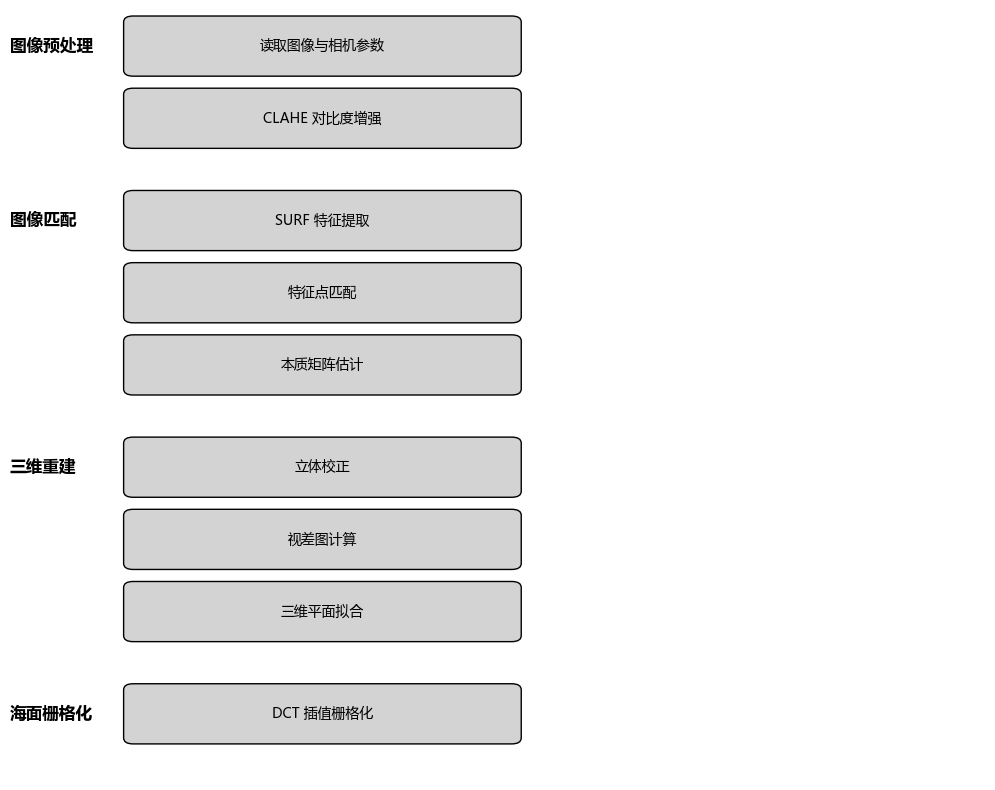

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.dates as mdates
# 设置中文字体和字号
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 10  # 全局字体大小
# 中文任务步骤
steps = [
    ("图像预处理", ["读取图像与相机参数", "CLAHE 对比度增强"]),
    ("图像匹配", ["SURF 特征提取", "特征点匹配", "本质矩阵估计"]),
    ("三维重建", ["立体校正", "视差图计算", "三维平面拟合"]),
    ("海面栅格化", ["DCT 插值栅格化"])
]

# 中文任务步骤
steps = [
    ("图像预处理", ["读取图像与相机参数", "CLAHE 对比度增强"]),
    ("图像匹配", ["SURF 特征提取", "特征点匹配", "本质矩阵估计"]),
    ("三维重建", ["立体校正", "视差图计算", "三维平面拟合"]),
    ("海面栅格化", ["DCT 插值栅格化"])
]

fig, ax = plt.subplots(figsize=(10, 8))
y = 0
box_width = 4
box_height = 0.8
x_center = 3
label_x = -0.3  # 阶段标题横坐标（进一步左移）

# 绘制流程框和阶段标题
for group, tasks in steps:
    ax.text(label_x, y + 0.4, group, fontsize=12, fontweight='bold',
            verticalalignment='center', horizontalalignment='left')
    for task in tasks:
        ax.add_patch(mpatches.FancyBboxPatch((1, y), box_width, box_height,
                                             boxstyle="round,pad=0.1", edgecolor='black', facecolor='lightgray'))
        ax.text(x_center, y + box_height / 2, task, ha='center', va='center', fontsize=10)
        y -= 1.2  # 框间距
    y -= 0.5  # 每个阶段之间增加间隔

# 添加箭头
y = 0
for group, tasks in steps:
    for i in range(len(tasks) - 1):
        start_y = y - box_height
        end_y = y - 1.2 + box_height / 2
        ax.annotate("", xy=(x_center, end_y), xytext=(x_center, start_y),
                    arrowprops=dict(arrowstyle="->", lw=1))
        y -= 1.2
    y -= 1.2  # 跨阶段箭头间距

# 图像设置
ax.set_xlim(0, 10)
ax.set_ylim(y - 1, 1)
ax.axis('off')
plt.tight_layout()
plt.show()


In [2]:
from graphviz import Digraph

dot = Digraph(comment='船载双目图像波浪参数反演流程', format='png')
dot.attr(rankdir='TB', size='8')

# 阶段标签（用作注释，不连线）
dot.attr('node', shape='plaintext')
dot.node('阶段1', '图像预处理')
dot.node('阶段2', '图像匹配')
dot.node('阶段3', '三维重建')
dot.node('阶段4', '海面栅格化')

# 正式流程节点
dot.attr('node', shape='box', style='rounded', fontname='Microsoft YaHei')

dot.node('A1', '读取图像与相机参数')
dot.node('A2', 'CLAHE 对比度增强')

dot.node('B1', 'SURF 特征提取')
dot.node('B2', '特征点匹配')
dot.node('B3', '本质矩阵估计')

dot.node('C1', '立体校正')
dot.node('C2', '视差图计算')
dot.node('C3', '三维平面拟合')

dot.node('D1', 'DCT 插值栅格化')

# 连接流程线
dot.edges([
    ('A1', 'A2'),
    ('A2', 'B1'),
    ('B1', 'B2'),
    ('B2', 'B3'),
    ('B3', 'C1'),
    ('C1', 'C2'),
    ('C2', 'C3'),
    ('C3', 'D1')
])

# 生成并预览图片
dot.render('双目图像波浪参数反演流程图', view=True)


'双目图像波浪参数反演流程图.png'

In [3]:
from graphviz import Digraph

dot = Digraph(comment='船载双目图像波浪参数反演流程', format='png')
dot.attr(rankdir='TB', size='8')

dot.attr('node', shape='box', style='rounded', fontname='Microsoft YaHei')

# 图像预处理阶段
with dot.subgraph(name='cluster_0') as c:
    c.attr(label='图像预处理', style='dashed', fontname='Microsoft YaHei')
    c.node('A1', '读取图像与相机参数')
    c.node('A2', 'CLAHE 对比度增强')
    c.edges([('A1', 'A2')])

# 图像匹配阶段
with dot.subgraph(name='cluster_1') as c:
    c.attr(label='图像匹配', style='dashed', fontname='Microsoft YaHei')
    c.node('B1', 'SURF 特征提取')
    c.node('B2', '特征点匹配')
    c.node('B3', '本质矩阵估计')
    c.edges([('B1', 'B2'), ('B2', 'B3')])

# 三维重建阶段
with dot.subgraph(name='cluster_2') as c:
    c.attr(label='三维重建', style='dashed', fontname='Microsoft YaHei')
    c.node('C1', '立体校正')
    c.node('C2', '视差图计算')
    c.node('C3', '三维平面拟合')
    c.edges([('C1', 'C2'), ('C2', 'C3')])

# 海面栅格化阶段
with dot.subgraph(name='cluster_3') as c:
    c.attr(label='海面栅格化', style='dashed', fontname='Microsoft YaHei')
    c.node('D1', 'DCT 插值栅格化')

# 跨阶段连接线
dot.edge('A2', 'B1')
dot.edge('B3', 'C1')
dot.edge('C3', 'D1')

# 生成并预览图片
dot.render('双目图像波浪参数反演流程图_改进版', view=True)


'双目图像波浪参数反演流程图_改进版.png'


风速对显著波高的皮尔逊相关系数: 0.6919


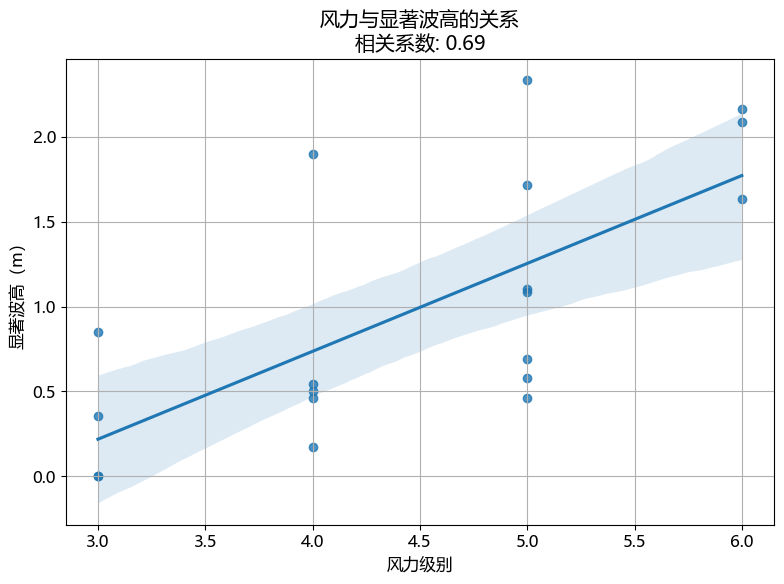

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '风']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['风力'] = pd.to_numeric(data['风'], errors='coerce')
data = data.dropna()

# 计算皮尔逊相关系数（y 对 x）
correlation = data['风力'].corr(data['显著波高'], method='pearson')
print(f"\n风速对显著波高的皮尔逊相关系数: {correlation:.4f}")

# 绘制以船速为 x，显著波高为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='风力', y='显著波高', data=data)
plt.title(f'风力与显著波高的关系\n相关系数: {correlation:.2f}')
plt.xlabel('风力级别')
plt.ylabel('显著波高（m）')
plt.grid(True)
plt.tight_layout()
plt.show()



船速对显著波高的皮尔逊相关系数: 0.5264


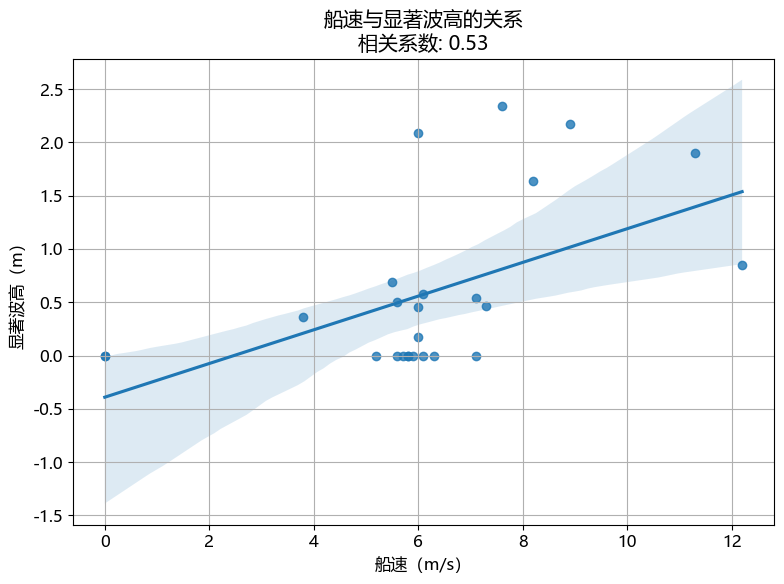

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '船速']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['船速'] = pd.to_numeric(data['船速'], errors='coerce')
data = data.dropna()

# 计算皮尔逊相关系数（y 对 x）
correlation = data['船速'].corr(data['显著波高'], method='pearson')
print(f"\n船速对显著波高的皮尔逊相关系数: {correlation:.4f}")

# 绘制以船速为 x，显著波高为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='船速', y='显著波高', data=data)
plt.title(f'船速与显著波高的关系\n相关系数: {correlation:.2f}')
plt.xlabel('船速（m/s）')
plt.ylabel('显著波高（m）')
plt.grid(True)
plt.tight_layout()
plt.show()


D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"



显著波高对船速的皮尔逊相关系数: 0.5264


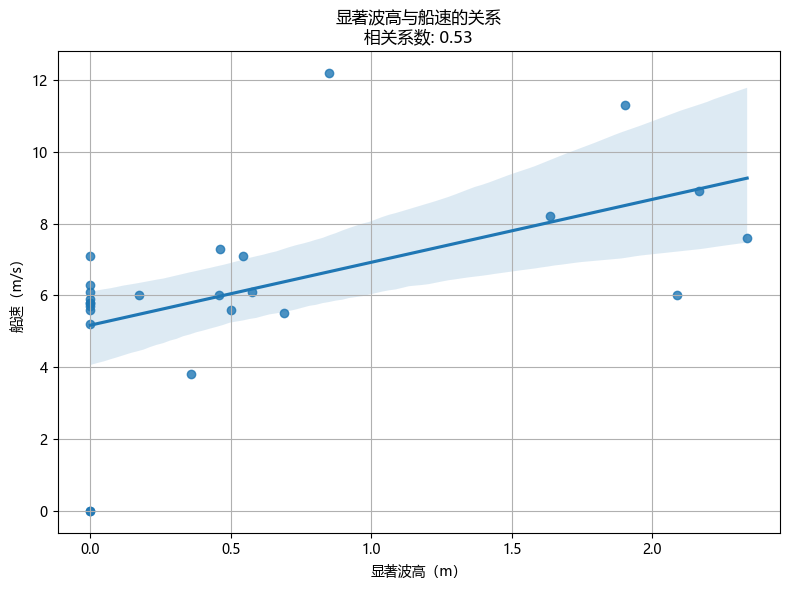

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '船速']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['船速'] = pd.to_numeric(data['船速'], errors='coerce')
data = data.dropna()

# 计算皮尔逊相关系数（x 对 y）
correlation = data['显著波高'].corr(data['船速'], method='pearson')
print(f"\n显著波高对船速的皮尔逊相关系数: {correlation:.4f}")

# 绘制以显著波高为 x，船速为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='显著波高', y='船速', data=data)
plt.title(f'显著波高与船速的关系\n相关系数: {correlation:.2f}')
plt.xlabel('显著波高（m）')
plt.ylabel('船速（m/s）')
plt.grid(True)
plt.tight_layout()
plt.show()



耗油量对显著波高的皮尔逊相关系数: 0.3382


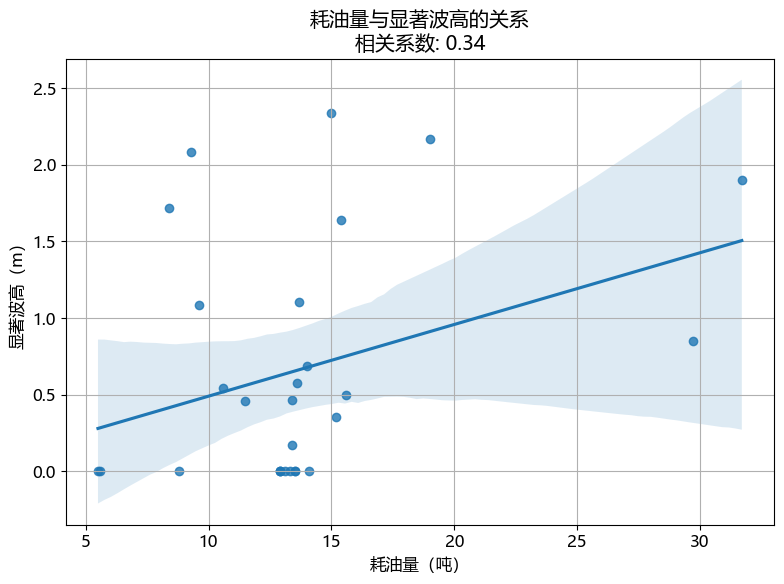

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '耗油量']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['耗油量'] = pd.to_numeric(data['耗油量'], errors='coerce')
data = data.dropna()

# 计算皮尔逊相关系数（y 对 x）
correlation = data['耗油量'].corr(data['显著波高'], method='pearson')
print(f"\n耗油量对显著波高的皮尔逊相关系数: {correlation:.4f}")

# 绘制以船速为 x，显著波高为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='耗油量', y='显著波高', data=data)
plt.title(f'耗油量与显著波高的关系\n相关系数: {correlation:.2f}')
plt.xlabel('耗油量（吨）')
plt.ylabel('显著波高（m）')
plt.grid(True)
plt.tight_layout()
plt.show()



显著波高对耗油量的皮尔逊相关系数: 0.3382


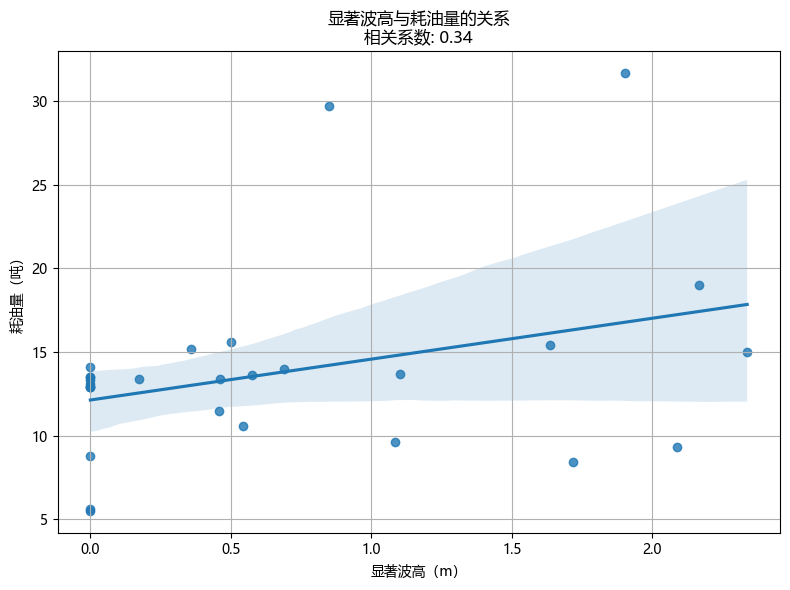

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '耗油量']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['耗油量'] = pd.to_numeric(data['耗油量'], errors='coerce')
data = data.dropna()

# 计算皮尔逊相关系数（显著波高对耗油量）
correlation = data['显著波高'].corr(data['耗油量'], method='pearson')
print(f"\n显著波高对耗油量的皮尔逊相关系数: {correlation:.4f}")

# 绘制以显著波高为 x，耗油量为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='显著波高', y='耗油量', data=data)
plt.title(f'显著波高与耗油量的关系\n相关系数: {correlation:.2f}')
plt.xlabel('显著波高（m）')
plt.ylabel('耗油量（吨）')
plt.grid(True)
plt.tight_layout()
plt.show()


D:\py\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\py\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"



海冰密集度对显著波高的皮尔逊相关系数: -0.7824


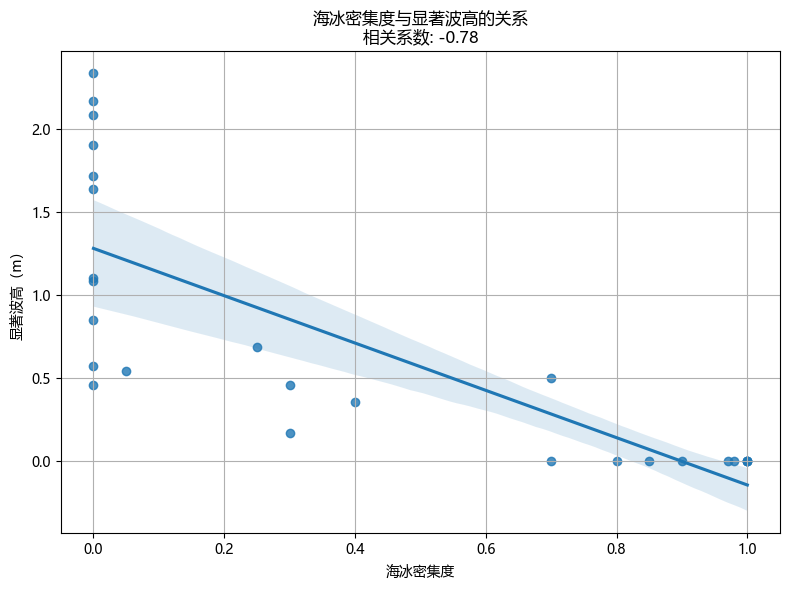

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '海冰密集度']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['海冰密集度'] = pd.to_numeric(data['海冰密集度'], errors='coerce')
data = data.dropna()

# 计算皮尔逊相关系数（y 对 x）
correlation = data['海冰密集度'].corr(data['显著波高'], method='pearson')
print(f"\n海冰密集度对显著波高的皮尔逊相关系数: {correlation:.4f}")

# 绘制以船速为 x，显著波高为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='海冰密集度', y='显著波高', data=data)
plt.title(f'海冰密集度与显著波高的关系\n相关系数: {correlation:.2f}')
plt.xlabel('海冰密集度')
plt.ylabel('显著波高（m）')
plt.grid(True)
plt.tight_layout()
plt.show()



风对显著波高的皮尔逊相关系数: 0.5712


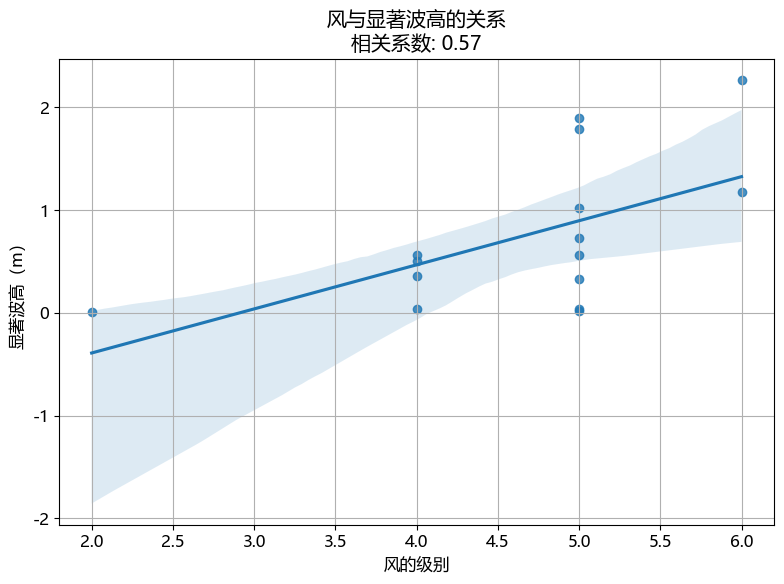

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取 Excel，使用第一行作为列名
file_path = r"E:\graduate_design\height2.xlsx"
df = pd.read_excel(file_path, header=0)

# 提取所需列并清洗数据
data = df[['显著波高', '风']].copy()
data['显著波高'] = pd.to_numeric(data['显著波高'], errors='coerce')
data['风'] = pd.to_numeric(data['风'], errors='coerce')
data = data.dropna()

# 去除显著波高为0的数据点
data = data[data['显著波高'] != 0]

# 计算皮尔逊相关系数（y 对 x）
correlation = data['风'].corr(data['显著波高'], method='pearson')
print(f"\n风对显著波高的皮尔逊相关系数: {correlation:.4f}")

# 绘制以风为 x，显著波高为 y 的回归图
plt.figure(figsize=(8, 6))
sns.regplot(x='风', y='显著波高', data=data)
plt.title(f'风与显著波高的关系\n相关系数: {correlation:.2f}')
plt.xlabel('风的级别')
plt.ylabel('显著波高（m）')
plt.grid(True)
plt.tight_layout()
plt.show()


Z shape: (4, 1024, 1024)


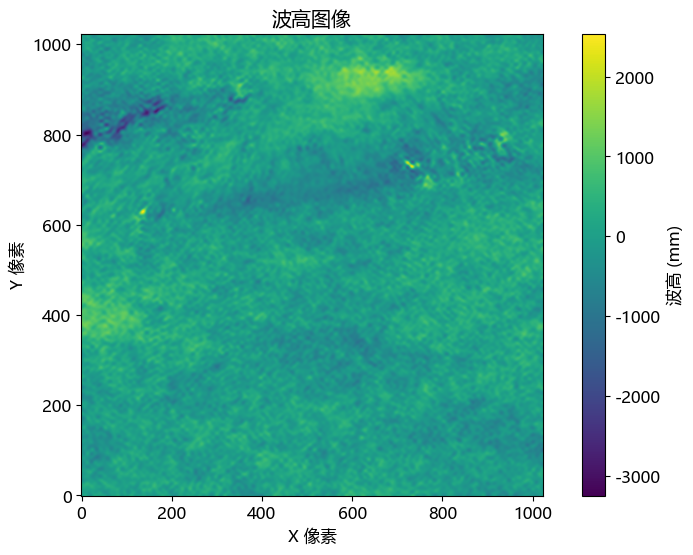

In [46]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 打开 NetCDF 文件
file_path = r"E:\graduate_design\test6\gridding\gridded.nc"
ds = nc.Dataset(file_path)

# 读取波高数据变量 Z（注意大小写）
Z = ds.variables['Z']  # 一般是 shape: (time, y, x)

# 检查形状
print("Z shape:", Z.shape)

# 读取第一帧的波高图像
z0 = Z[0, :, :]  # 第一个时间点的二维波高图像

# 绘图
plt.figure(figsize=(10, 6))
plt.imshow(z0, cmap='viridis', origin='lower')
plt.colorbar(label='波高 (mm)')
plt.title("波高图像")
plt.xlabel("X 像素")
plt.ylabel("Y 像素")
plt.show()


Z shape: (5, 1024, 1024)


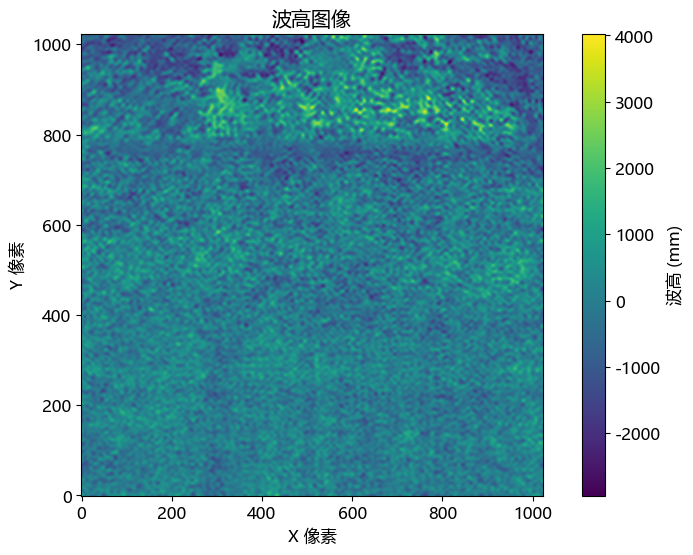

In [78]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 打开 NetCDF 文件
file_path = r"E:\graduate_design\test7\0914\gridding\gridded.nc"
ds = nc.Dataset(file_path)

# 读取波高数据变量 Z（注意大小写）
Z = ds.variables['Z']  # 一般是 shape: (time, y, x)

# 检查形状
print("Z shape:", Z.shape)

# 读取第一帧的波高图像
z0 = Z[0, :, :]  # 第一个时间点的二维波高图像

# 绘图
plt.figure(figsize=(10, 6))
plt.imshow(z0, cmap='viridis', origin='lower')
plt.colorbar(label='波高 (mm)')
plt.title("波高图像")
plt.xlabel("X 像素")
plt.ylabel("Y 像素")
plt.show()


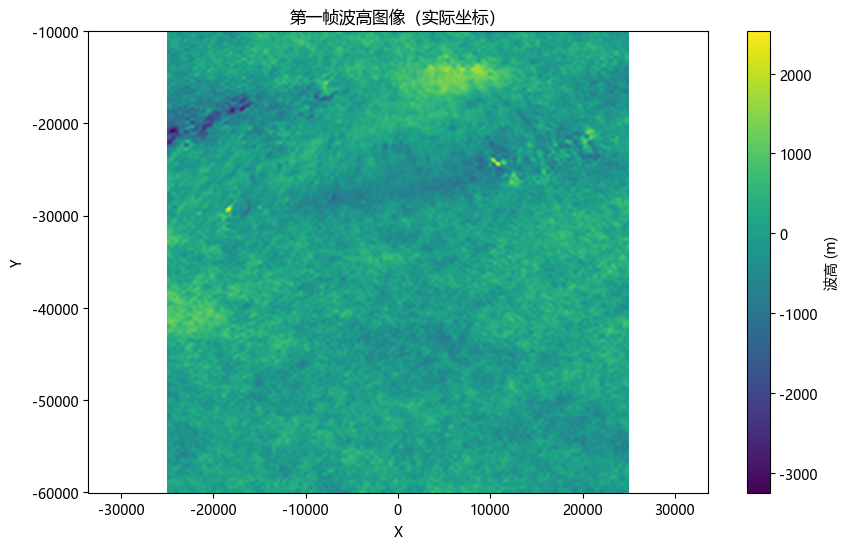

In [12]:
X = ds.variables['X_grid'][:]
Y = ds.variables['Y_grid'][:]
Z0 = ds.variables['Z'][0, :, :]

plt.figure(figsize=(10, 6))
plt.pcolormesh(X, Y, Z0, cmap='viridis', shading='auto')
plt.colorbar(label='波高 (m)')
plt.title("第一帧波高图像（实际坐标）")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.show()


In [12]:
# 安装必要的库（如果还没安装的话）
# !pip install netCDF4 numpy

import netCDF4 as nc
import numpy as np

# === 设置文件路径 ===
file_path = r"E:\graduate_design\test7\0911\gridding\gridded.nc"

# === 打开 NetCDF 文件 ===
dataset = nc.Dataset(file_path)

# 查看文件中有哪些变量（方便确认波高变量名）
print("Variables in the file:", dataset.variables.keys())

# === 选择正确的变量名 ===
# 假设波高变量名是 'Z'，请根据输出确认后修改
var_name = 'Z'  # ← 根据实际情况修改
z = dataset.variables[var_name][:]  # 通常是 (time, y, x)

# === 取出第一帧数据 ===
z_first_frame = z[2, :, :]/1000.0

# === 去除无效值（如 NaN） ===
z_valid = z_first_frame[~np.isnan(z_first_frame)]

# === 计算统计量 ===
z_min = np.min(z_valid)
q1 = np.percentile(z_valid, 25)
median = np.median(z_valid)
mean = np.mean(z_valid)
q3 = np.percentile(z_valid, 75)
z_max = np.max(z_valid)

# === 输出结果 ===
print(f"第一帧统计结果：")
print(f"最小值 (Z_min): {z_min:.4f}")
print(f"第一四分位数 (Q1): {q1:.4f}")
print(f"中位数 (Median): {median:.4f}")
print(f"平均值 (Mean): {mean:.4f}")
print(f"第三四分位数 (Q3): {q3:.4f}")
print(f"最大值 (Z_max): {z_max:.4f}")

# === 关闭文件 ===
dataset.close()


Variables in the file: dict_keys(['scale', 'count', 'time', 'workdir', 'X_grid', 'Y_grid', 'Kx', 'Ky', 'Z', 'maskZ', 'cam0images', 'cam0masks'])
第一帧统计结果：
最小值 (Z_min): -2.6111
第一四分位数 (Q1): -0.2827
中位数 (Median): 0.0017
平均值 (Mean): -0.0129
第三四分位数 (Q3): 0.2708
最大值 (Z_max): 2.9080


✅ 总体预测精度: 75.00%


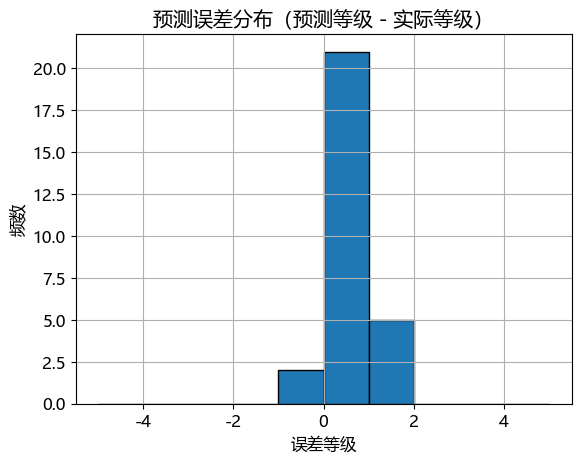

In [55]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False
# 读取Excel文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 只保留相关列
df = df[['日期', '波级', '显著波高']].copy()
df.columns = ['date', 'true_level', 'Hs']  # 重命名列

# 去除缺失值
df.dropna(inplace=True)

# 确保数据格式正确
df['true_level'] = df['true_level'].astype(int)
df['Hs'] = pd.to_numeric(df['Hs'], errors='coerce')

# 定义WMO判断函数
def hs_to_wmo_level(hs):
    if hs == 0:
        return 0
    elif hs <= 0.10:
        return 1
    elif hs <= 0.50:
        return 2
    elif hs <= 1.25:
        return 3
    elif hs <= 2.50:
        return 4
    elif hs <= 4.00:
        return 5
    elif hs <= 6.00:
        return 6
    elif hs <= 9.00:
        return 7
    elif hs <= 14.00:
        return 8
    else:
        return 9

# 应用判断函数
df['predicted_level'] = df['Hs'].apply(hs_to_wmo_level)

# 计算精度
df['correct'] = df['true_level'] == df['predicted_level']
accuracy = df['correct'].mean() * 100

print(f"✅ 总体预测精度: {accuracy:.2f}%")

# 可视化误差分布（可选）
import matplotlib.pyplot as plt
df['error'] = df['predicted_level'] - df['true_level']
plt.hist(df['error'], bins=range(-5,6), edgecolor='black')
plt.title("预测误差分布（预测等级 - 实际等级）")
plt.xlabel("误差等级")
plt.ylabel("频数")
plt.grid(True)
plt.show()


✅ 总体预测精度: 58.82%


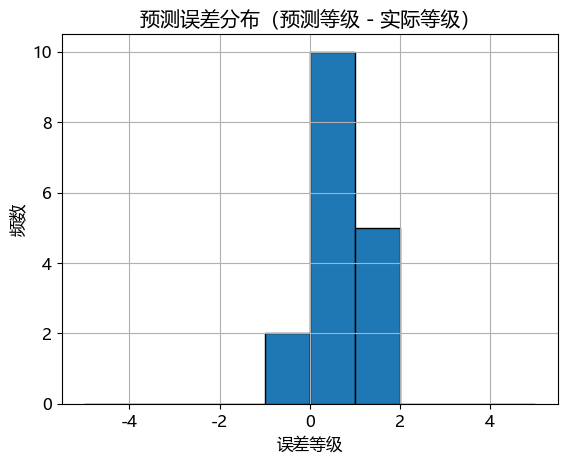

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 读取Excel文件
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)

# 只保留相关列
df = df[['日期', '波级', '显著波高']].copy()
df.columns = ['date', 'true_level', 'Hs']  # 重命名列

# 去除缺失值
df.dropna(inplace=True)

# 确保数据格式正确
df['true_level'] = df['true_level'].astype(int)
df['Hs'] = pd.to_numeric(df['Hs'], errors='coerce')

# ===== 新增：去除波级为0的数据 =====
df = df[df['true_level'] != 0].copy()

# 定义WMO判断函数
def hs_to_wmo_level(hs):
    if hs == 0:
        return 0
    elif hs <= 0.10:
        return 1
    elif hs <= 0.50:
        return 2
    elif hs <= 1.25:
        return 3
    elif hs <= 2.50:
        return 4
    elif hs <= 4.00:
        return 5
    elif hs <= 6.00:
        return 6
    elif hs <= 9.00:
        return 7
    elif hs <= 14.00:
        return 8
    else:
        return 9

# 应用判断函数
df['predicted_level'] = df['Hs'].apply(hs_to_wmo_level)

# 计算精度
df['correct'] = df['true_level'] == df['predicted_level']
accuracy = df['correct'].mean() * 100

print(f"✅ 总体预测精度: {accuracy:.2f}%")

# 可视化误差分布（可选）
df['error'] = df['predicted_level'] - df['true_level']
plt.hist(df['error'], bins=range(-5, 6), edgecolor='black')
plt.title("预测误差分布（预测等级 - 实际等级）")
plt.xlabel("误差等级")
plt.ylabel("频数")
plt.grid(True)
plt.show()



🔷 混淆矩阵：
        预测波级 0  预测波级 1  预测波级 2  预测波级 3  预测波级 4
实际波级 0      11       0       0       0       0
实际波级 1       0       0       2       0       0
实际波级 2       0       0       3       3       0
实际波级 3       0       0       0       1       0
实际波级 4       0       0       0       2       6


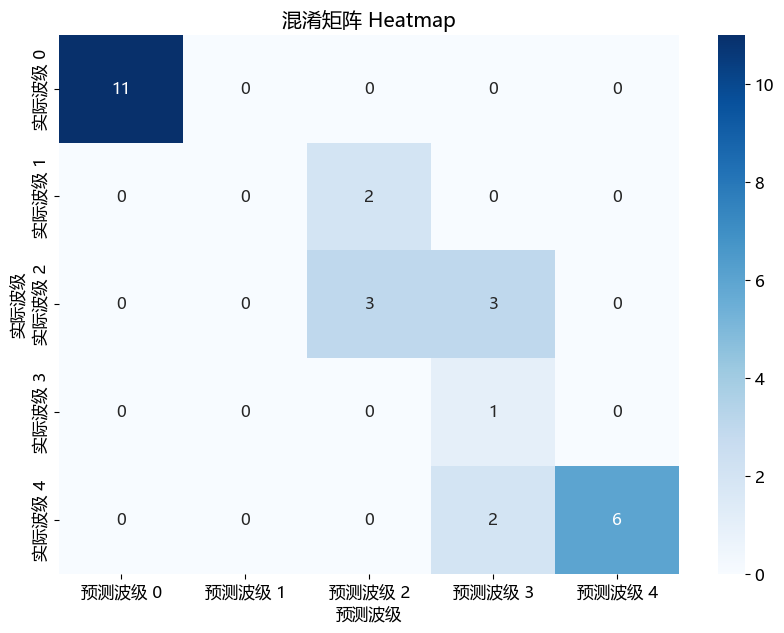


🔷 每个波级的识别指标：
   precision  recall  f1-score  support
0   1.000000    1.00  1.000000     11.0
1   0.000000    0.00  0.000000      2.0
2   0.600000    0.50  0.545455      6.0
3   0.166667    1.00  0.285714      1.0
4   1.000000    0.75  0.857143      8.0


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# === 读取数据 ===
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)[['日期', '波级', '显著波高']].dropna()
df.columns = ['date', 'true_level', 'Hs']
df['true_level'] = df['true_level'].astype(int)

# === WMO 海况等级映射函数 ===
def hs_to_wmo_level(hs):
    if hs == 0:
        return 0
    elif hs <= 0.10:
        return 1
    elif hs <= 0.50:
        return 2
    elif hs <= 1.25:
        return 3
    elif hs <= 2.50:
        return 4
    elif hs <= 4.00:
        return 5
    elif hs <= 6.00:
        return 6
    elif hs <= 9.00:
        return 7
    elif hs <= 14.00:
        return 8
    else:
        return 9

# === 应用预测 ===
df['predicted_level'] = df['Hs'].apply(hs_to_wmo_level)

# === 混淆矩阵 ===
levels = sorted(set(df['true_level']).union(set(df['predicted_level'])))
cm = confusion_matrix(df['true_level'], df['predicted_level'], labels=levels)

# === 显示混淆矩阵表格 ===
cm_df = pd.DataFrame(cm, index=[f'实际波级 {i}' for i in levels],
                         columns=[f'预测波级 {i}' for i in levels])
print("\n🔷 混淆矩阵：")
print(cm_df)

# === 可视化混淆矩阵热力图（可选） ===
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("混淆矩阵 Heatmap")
plt.ylabel("实际波级")
plt.xlabel("预测波级")
plt.show()

# === 分类报告 ===
report = classification_report(df['true_level'], df['predicted_level'], labels=levels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
print("\n🔷 每个波级的识别指标：")
print(report_df[['precision', 'recall', 'f1-score', 'support']].loc[[str(i) for i in levels]])



🔷 混淆矩阵：
        预测波级 1  预测波级 2  预测波级 3  预测波级 4
实际波级 1       0       2       0       0
实际波级 2       0       3       3       0
实际波级 3       0       0       1       0
实际波级 4       0       0       2       6


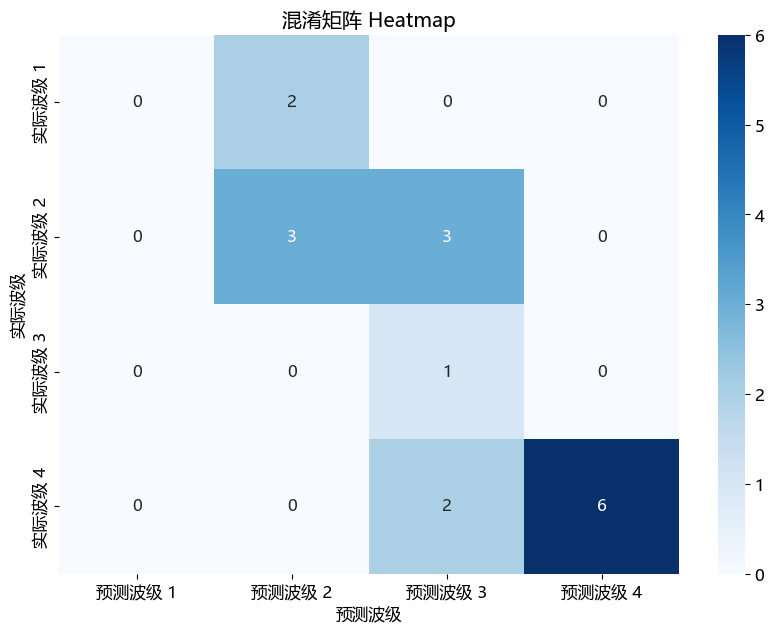


🔷 每个波级的识别指标：
   precision  recall  f1-score  support
1   0.000000    0.00  0.000000      2.0
2   0.600000    0.50  0.545455      6.0
3   0.166667    1.00  0.285714      1.0
4   1.000000    0.75  0.857143      8.0


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# === 读取数据 ===
file_path = r"E:\graduate_design\height.xlsx"
df = pd.read_excel(file_path)[['日期', '波级', '显著波高']].dropna()
df.columns = ['date', 'true_level', 'Hs']
df['true_level'] = df['true_level'].astype(int)

# === WMO 海况等级映射函数 ===
def hs_to_wmo_level(hs):
    if hs == 0:
        return 0
    elif hs <= 0.10:
        return 1
    elif hs <= 0.50:
        return 2
    elif hs <= 1.25:
        return 3
    elif hs <= 2.50:
        return 4
    elif hs <= 4.00:
        return 5
    elif hs <= 6.00:
        return 6
    elif hs <= 9.00:
        return 7
    elif hs <= 14.00:
        return 8
    else:
        return 9

# === 应用预测 ===
df['predicted_level'] = df['Hs'].apply(hs_to_wmo_level)

# === ⚡ 去除 true_level 为 0 的行 ===
df = df[df['true_level'] != 0]

# === 混淆矩阵 ===
levels = sorted(set(df['true_level']).union(set(df['predicted_level'])))
cm = confusion_matrix(df['true_level'], df['predicted_level'], labels=levels)

# === 显示混淆矩阵表格 ===
cm_df = pd.DataFrame(cm, index=[f'实际波级 {i}' for i in levels],
                         columns=[f'预测波级 {i}' for i in levels])
print("\n🔷 混淆矩阵：")
print(cm_df)

# === 可视化混淆矩阵热力图（可选） ===
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("混淆矩阵 Heatmap")
plt.ylabel("实际波级")
plt.xlabel("预测波级")
plt.show()

# === 分类报告 ===
report = classification_report(df['true_level'], df['predicted_level'], labels=levels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
print("\n🔷 每个波级的识别指标：")
print(report_df[['precision', 'recall', 'f1-score', 'support']].loc[[str(i) for i in levels]])


In [80]:
from sklearn.metrics import classification_report, confusion_matrix

# 真实值与预测值
y_true = df['实际波级']
y_pred = df['预测波级']

# 计算分类报告
report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

# 转换为DataFrame并提取等级行
levels = sorted(set(y_true).union(set(y_pred)))
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.loc[[str(i) for i in levels]]

# 计算总体准确率（accuracy）并添加为新行
overall_accuracy = (y_true == y_pred).mean()
summary_row = pd.DataFrame({
    'precision': [None],
    'recall': [None],
    'f1-score': [overall_accuracy],
    'support': [len(y_true)]
}, index=['总体准确率'])

# 合并到原指标表
final_report_df = pd.concat([report_df, summary_row])

# 显示结果
print("\n🔍 每个波级的识别指标（含总体准确率）：")
print(final_report_df)


KeyError: '实际波级'